In [13]:
import pandas as pd
import json
import networkx as nx
import matplotlib.pyplot as plt

In [14]:
with open('./security_data_assignment.json') as file:
    json_data = json.load(file)

print(json_data['metadata'])
events = pd.DataFrame(json_data['events'])
entities = pd.DataFrame(json_data['entities'])
relationships = pd.DataFrame(json_data['relationships'])

#attack_scenarios = pd.DataFrame(json_data['ground_truth']['attack_scenarios'])

{'num_true_positive_scenarios': 3, 'fp_tp_ratio': 20, 'timespan': 7, 'start_time': '2026-06-03T00:01:09.718490', 'end_time': '2026-06-10T00:01:09.718490', 'num_events': 357, 'num_entities': 487, 'num_relationships': 1374}


In [15]:
events

,id,type,timestamp,severity,description,alert_style,alert_message
0,f8ea18c3-d35b-470c-8067-5748b15e4528,Authentication,2026-06-03T19:26:52.210693,6,Login from unusual geographic location,behavioral,BEHAVIOR ANOMALY: Unusual authentication patte...
1,e838eea3-cbae-420e-a977-646fa08fcaa5,Defense Evasion,2026-06-03T23:34:24.430799,9,Security service stopped or disabled,raw_telemetry,Service state change: outlook.exe service stop...
2,d524c6c0-1141-4217-bd2e-5f7398a082e3,Privilege Operation,2026-06-04T01:07:56.239638,8,New user account created with admin privileges,rules_based,ADMIN ACTION ALERT: New user account created w...
3,3e054172-7d3e-46c9-9794-a42a06c0fb90,Data Access,2026-06-04T02:01:23.071498,7,Configuration files modified,rules_based,FILE ACCESS ALERT: Configuration files modifie...
4,7d5cb5fd-8b6b-4a80-8a1a-da8c356b10b3,Exfiltration,2026-06-04T03:29:24.171435,8,Encrypted communication to rare domain,raw_telemetry,RAW_TELEMETRY ALERT: Encrypted communication t...
...,...,...,...,...,...,...,...
352,058cf3e0-63f3-4c0f-85a8-45ceee4c9689,Authentication,2026-06-02T18:06:17.240032,3,Login from unusual location,behavioral,BEHAVIOR ANOMALY: Unusual authentication patte...
353,99cec239-5976-4337-b9a3-d76a2551d8d7,Authentication,2026-06-03T06:36:37.971773,3,Login outside business hours,raw_telemetry,RAW_TELEMETRY ALERT: Login outside business ho...
354,eef691a0-a101-4e92-b247-cee63624ca66,Data Access,2026-06-02T14:27:39.751749,5,Database query with excessive results,raw_telemetry,RAW_TELEMETRY ALERT: Database query with exces...
355,7b2670be-417c-492b-83c1-80dd96f12ac8,Exfiltration,2026-06-03T03:06:20.102611,1,Data transfer during off-hours,raw_telemetry,RAW_TELEMETRY ALERT: Data transfer during off-...


In [16]:
entities

,id,type,name,properties
0,64296679-e738-49af-b388-dd40d1d82046,Host,DC-473,"{'hostname': 'DC-473', 'ip_address': '192.168...."
1,d8bcd64a-963b-4b05-8703-cbeb4ac1d673,Host,WS-895,"{'hostname': 'WS-895', 'ip_address': '192.168...."
2,1129d5f7-e696-49d1-a563-50130e22c0e7,User,David Miller,"{'username': 'david.miller', 'role': 'User', '..."
3,9dc2bf0a-4144-48a8-9085-945bd3f5cb69,User,Maria Brown,"{'username': 'maria.brown', 'role': 'Developer..."
4,705f282b-f4b5-4647-b658-add9a2c7f37a,File,policy78.jar,"{'path': 'C:\Users\Downloads', 'name': 'policy..."
...,...,...,...,...
482,6d0ed87e-1970-4159-aeaa-5f32d1ecdc0c,Host,WS-758,"{'hostname': 'WS-758', 'ip_address': '192.168...."
483,2b85e41d-d023-4b63-8b68-42558b9157c4,Host,SRV-979,"{'hostname': 'SRV-979', 'ip_address': '192.168..."
484,4beab54a-6c5c-406f-b86e-28ec58f1ae9e,User,Jane Johnson,"{'username': 'jane.johnson1', 'role': 'User', ..."
485,9b3b2b60-723c-4f35-b468-df9a677458e0,NetworkConnection,192.168.168.175:53 -> 192.168.147.50,"{'source_ip': '192.168.168.175', 'dest_ip': '1..."


In [17]:
relationships

,source,target,weight,type
0,f8ea18c3-d35b-470c-8067-5748b15e4528,1129d5f7-e696-49d1-a563-50130e22c0e7,1.000,related_to
1,f8ea18c3-d35b-470c-8067-5748b15e4528,64296679-e738-49af-b388-dd40d1d82046,1.000,related_to
2,f8ea18c3-d35b-470c-8067-5748b15e4528,9dc2bf0a-4144-48a8-9085-945bd3f5cb69,1.000,related_to
3,f8ea18c3-d35b-470c-8067-5748b15e4528,d8bcd64a-963b-4b05-8703-cbeb4ac1d673,1.000,related_to
4,f8ea18c3-d35b-470c-8067-5748b15e4528,792134de-e825-4cef-959e-929663f02bf5,1.000,related_to
...,...,...,...,...
1369,7b2670be-417c-492b-83c1-80dd96f12ac8,4beab54a-6c5c-406f-b86e-28ec58f1ae9e,0.716,related_to
1370,7b2670be-417c-492b-83c1-80dd96f12ac8,2b85e41d-d023-4b63-8b68-42558b9157c4,0.716,related_to
1371,ca31e36e-8153-43a0-9a0e-82b7b3dba7cc,535be709-e0fc-46a1-95d0-ac74642bbe59,0.560,related_to
1372,ca31e36e-8153-43a0-9a0e-82b7b3dba7cc,9b3b2b60-723c-4f35-b468-df9a677458e0,0.560,related_to


In [7]:
attack_scenarios

NameError: name 'attack_scenarios' is not defined

In [34]:
'''
Sanity Check
====================================================================================
The event_ids that appear in the ground_truth.attack_scenarios array are precisely
those that are listed in ground_truth.true_positive_events.
'''

e = [event for i in range(len(attack_scenarios)) for event in attack_scenarios['event_ids'][i]]
print(set(e) == set(json_data['ground_truth']['true_positive_events'])) # should print true

'''
Likewise, the entity_ids that appear in the ground_truth.attack_scenarios array are precisely
those that are listed in ground_truth.true_positive_entities.
'''

e = [entity for i in range(len(attack_scenarios)) for entity in attack_scenarios['entity_ids'][i]]
print(set(e) == set(json_data['ground_truth']['true_positive_entities'])) # should print true

True
True


In [18]:
def create_bipartite_graph(part1, part2, edges) -> nx.Graph:
    """Load json file and return a bipartite weighted graph.

    Nodes are the `id` values from `events` and `entities`.
    Edges are created from `relationships` with the edge attribute `weight` set
    from the relationship's `weight` field. Each node gets attributes:
    - `kind`: either 'event' or 'entity'
    - `bipartite`: 0 for events, 1 for entities
    """
    G = nx.Graph()

    part1_ids = part1["id"]
    part2_ids = part2["id"]

    for nid in part1_ids:
        G.add_node(nid, bipartite=0)
    for nid in part2_ids:
        G.add_node(nid, bipartite=1)

    for i, e in edges.iterrows():
        src = e["source"]
        tgt = e["target"]
        weight = e["weight"]
        rtype = e["type"]

        if src is None or tgt is None:
            continue

        # Ensure nodes exist in graph (in case relationships reference missing ids)
        if src not in G:
            print("source node not in G")
            G.add_node(src, kind=("event" if src in event_ids else "entity"), bipartite=(0 if src in event_ids else 1))

        if tgt not in G:
            print("target node not in G")
            G.add_node(tgt, kind=("event" if tgt in event_ids else "entity"), bipartite=(0 if tgt in event_ids else 1))

        G.add_edge(src, tgt, weight=weight, type=rtype)

    return G

def connected_components_sorted(G: nx.Graph):
    """Return connected components sorted by size (descending)."""
    comps = list(nx.connected_components(G))
    comps.sort(key=len, reverse=True)
    return comps

Loaded graph: 844 nodes, 1374 edges


/tmp/ipykernel_3267218/553236200.py:16: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(i)


65


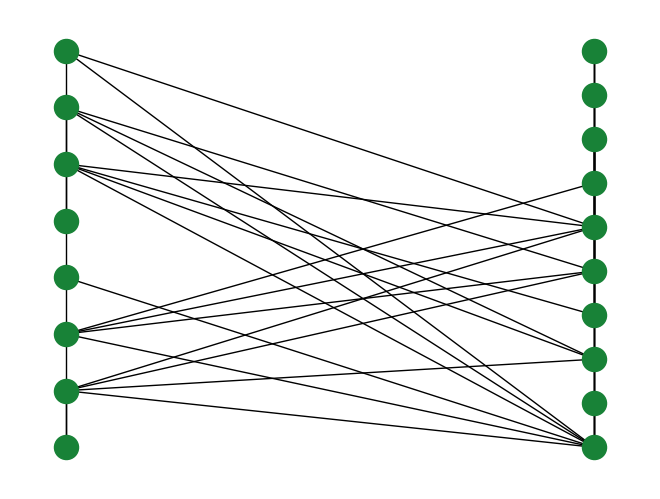

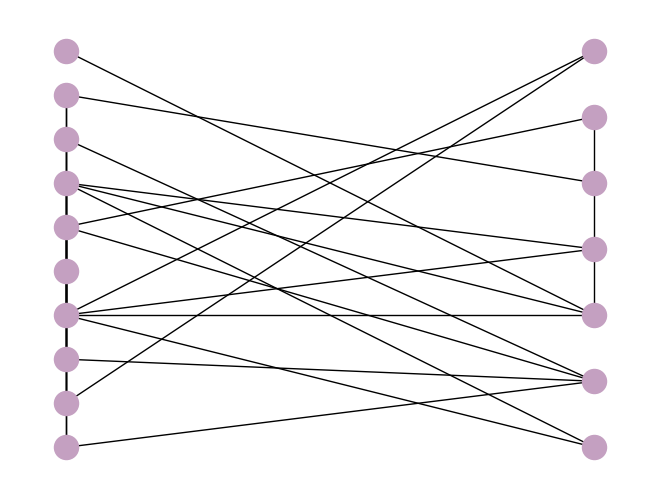

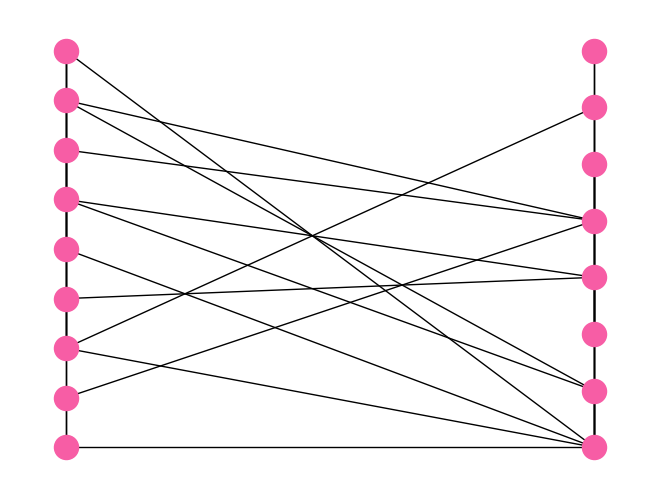

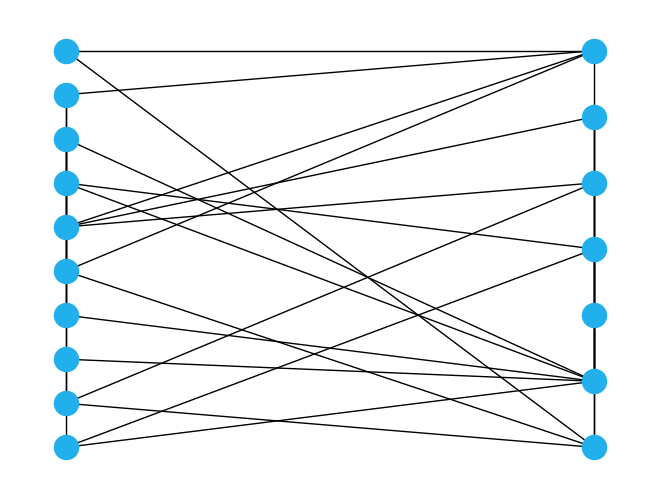

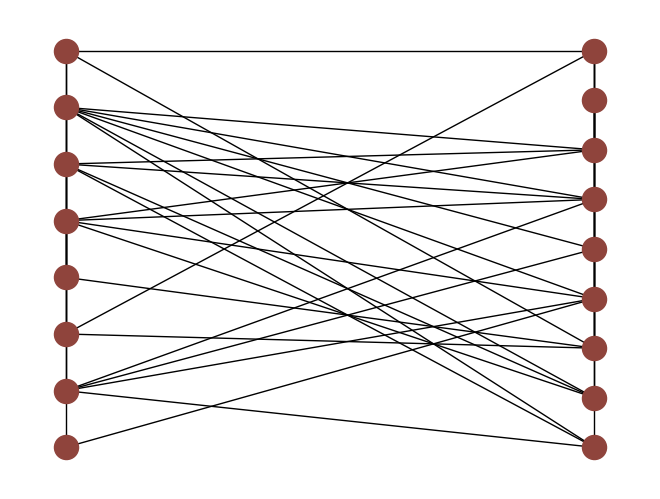

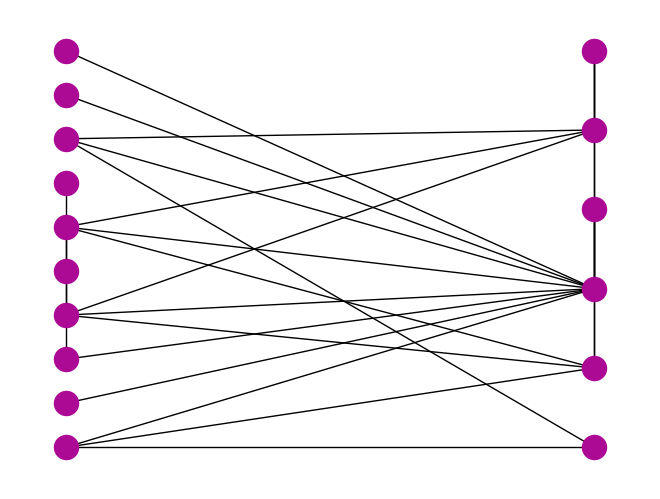

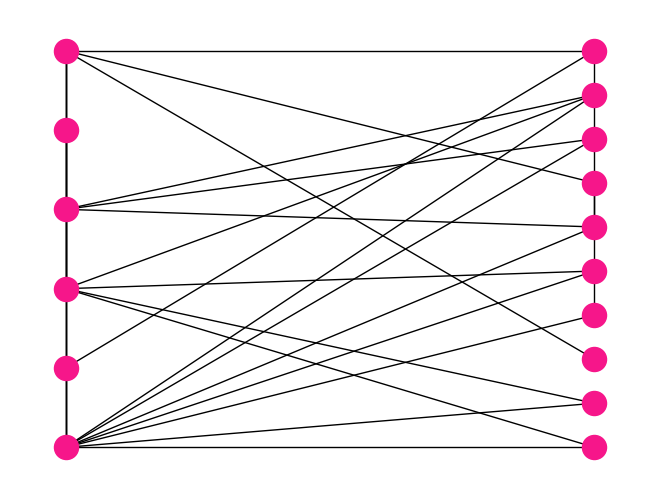

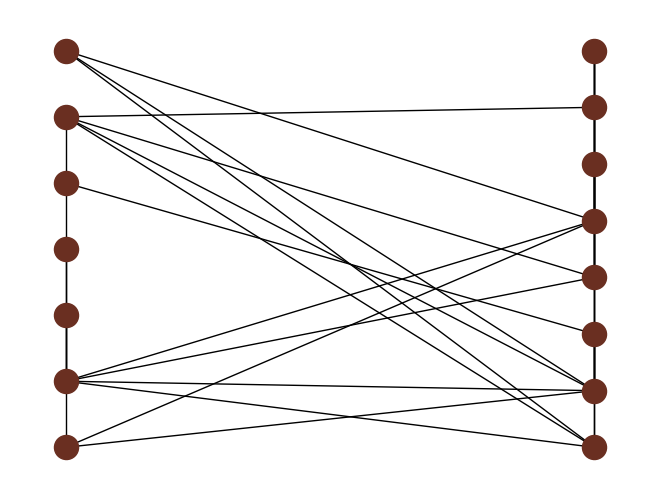

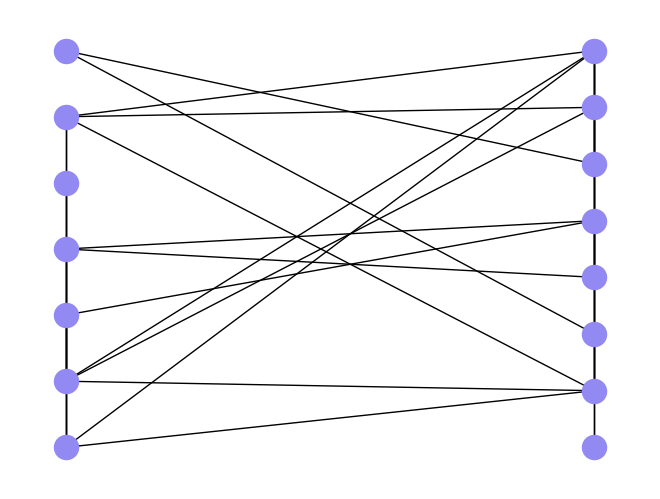

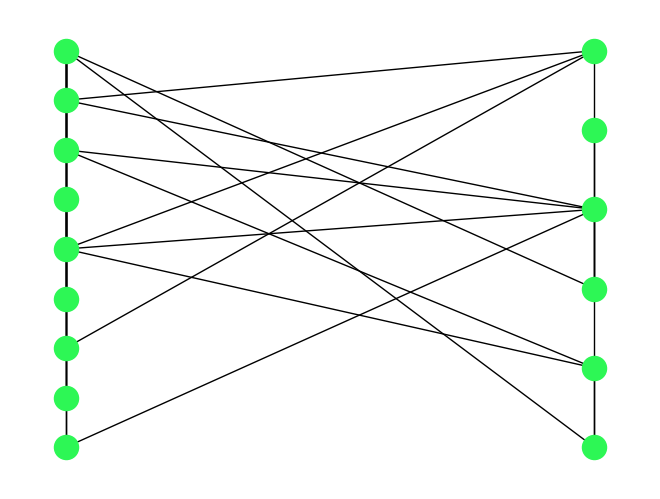

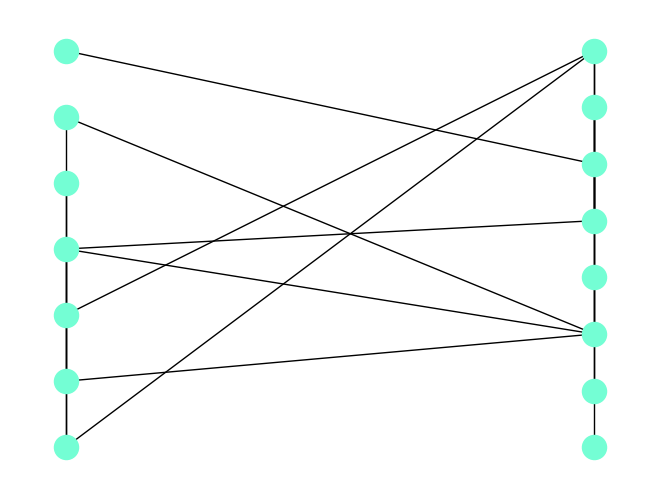

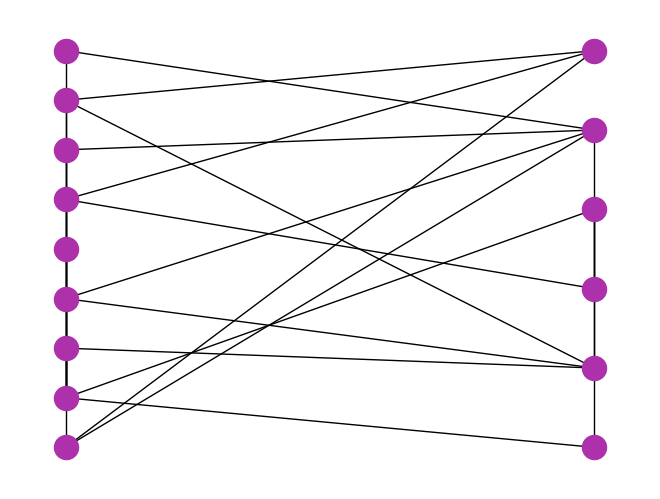

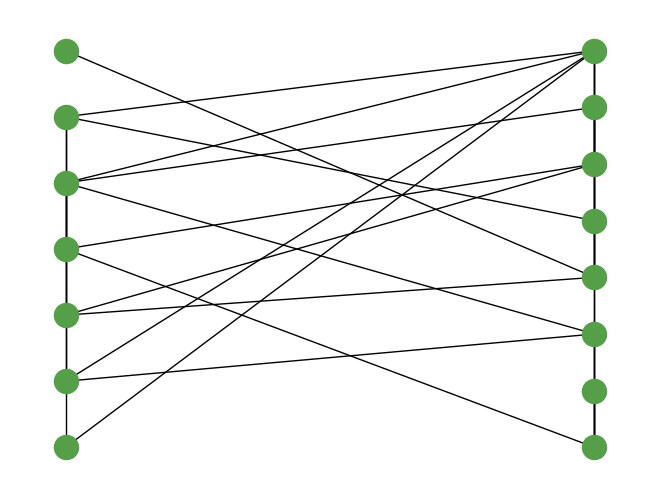

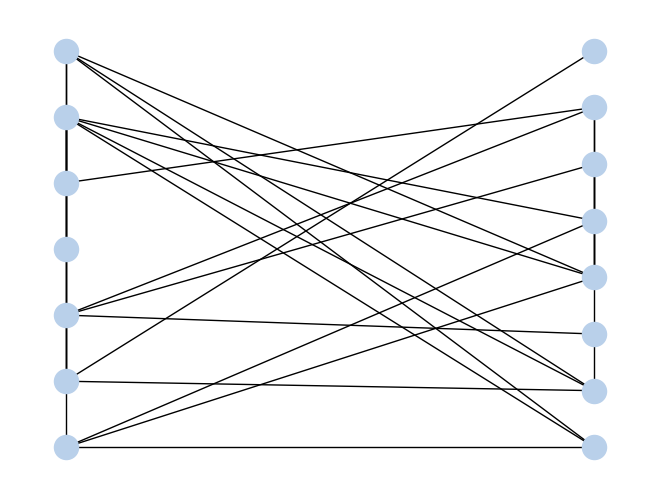

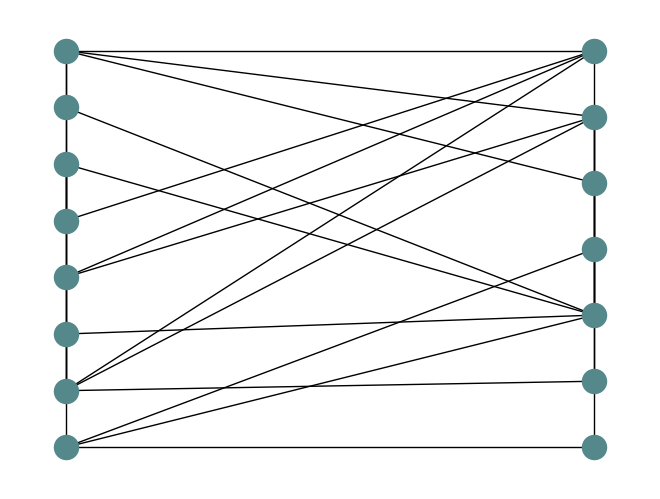

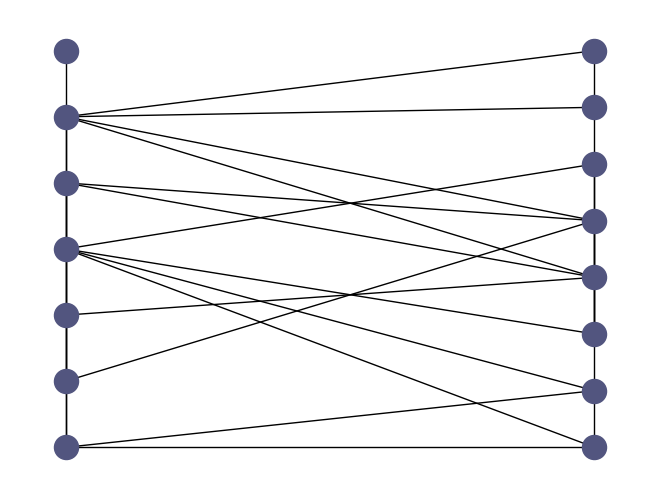

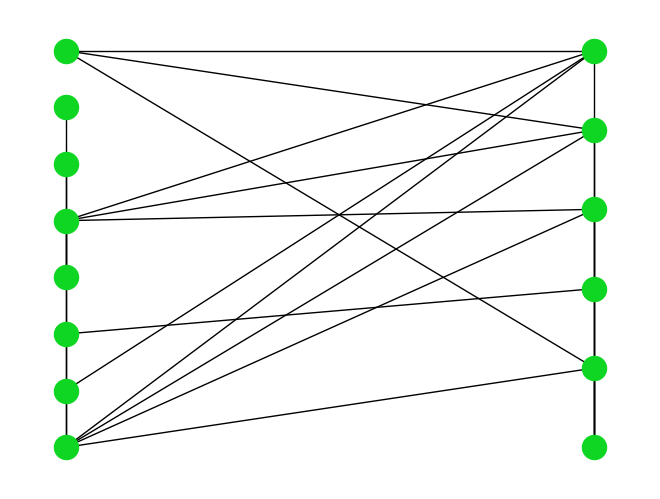

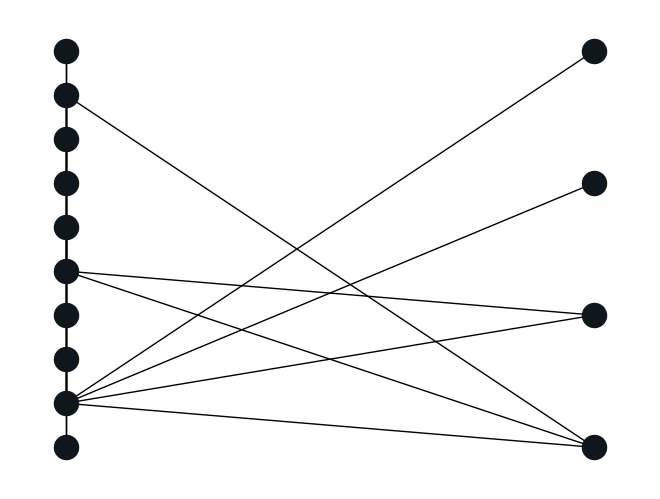

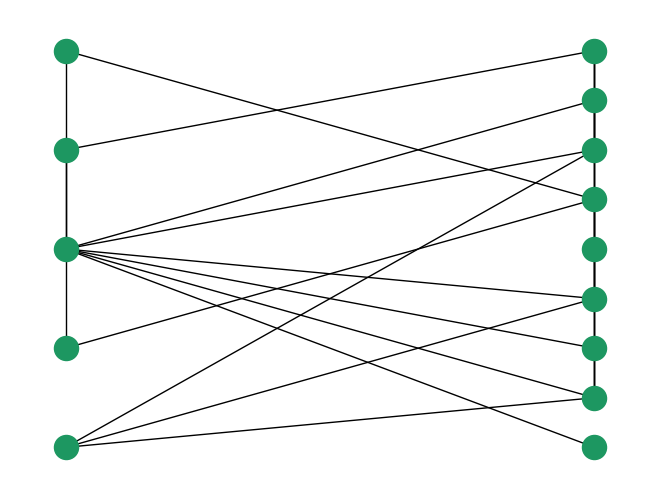

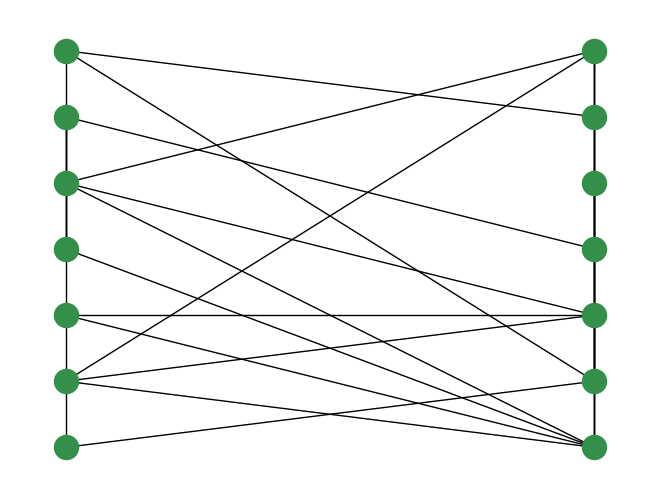

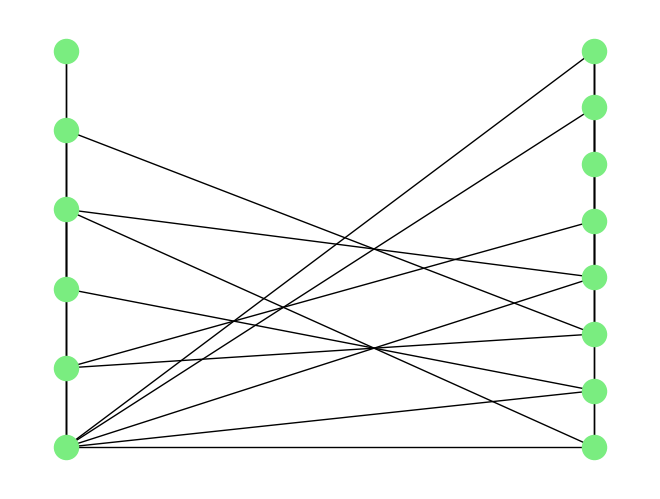

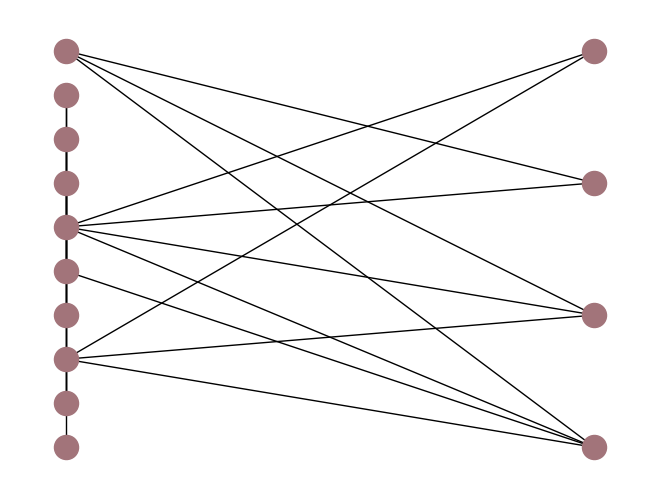

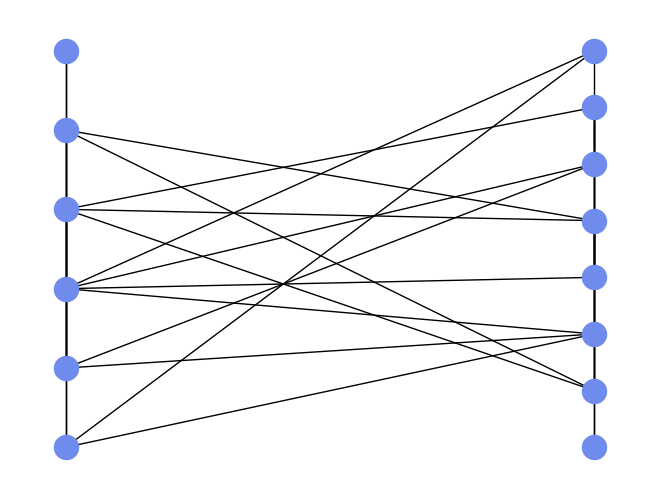

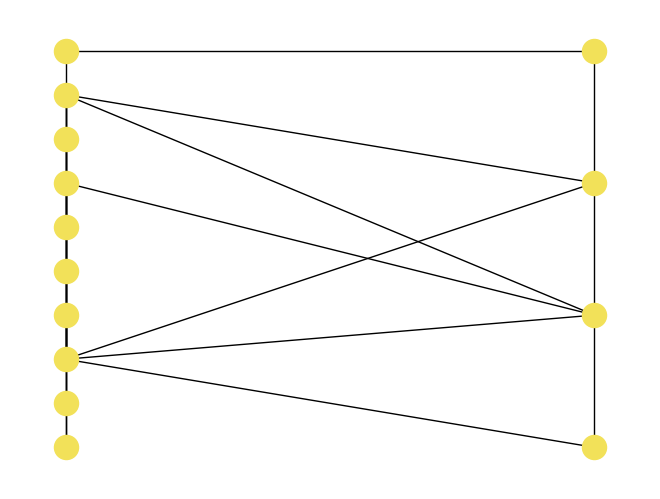

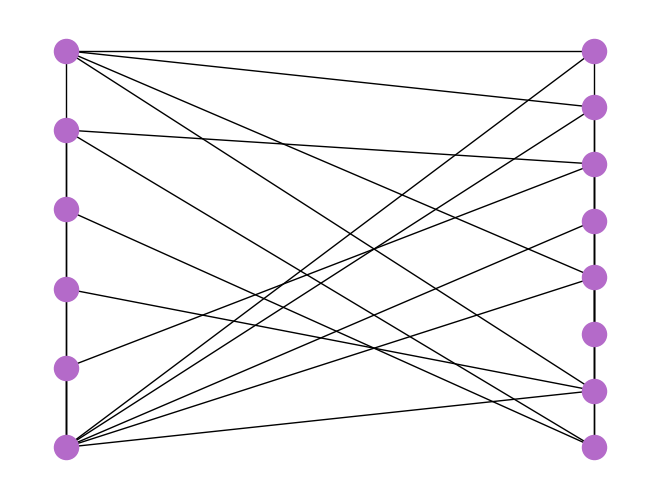

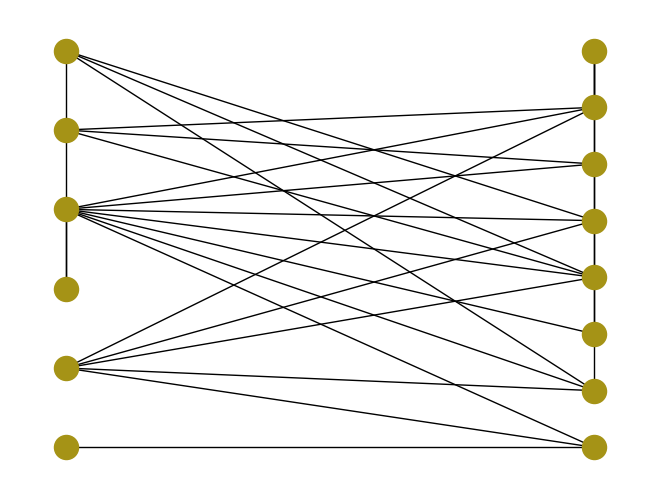

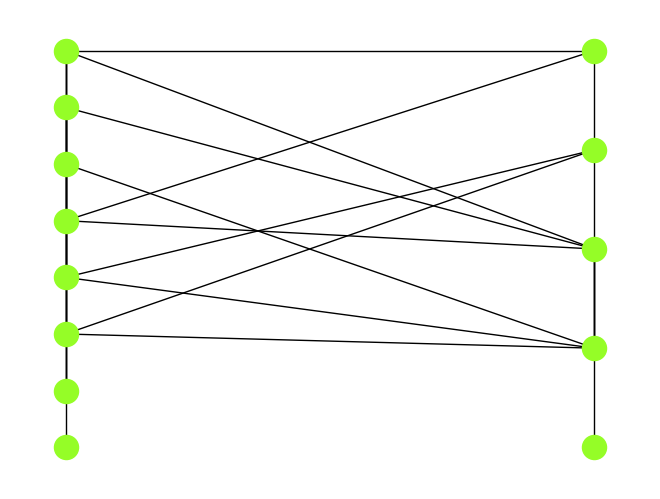

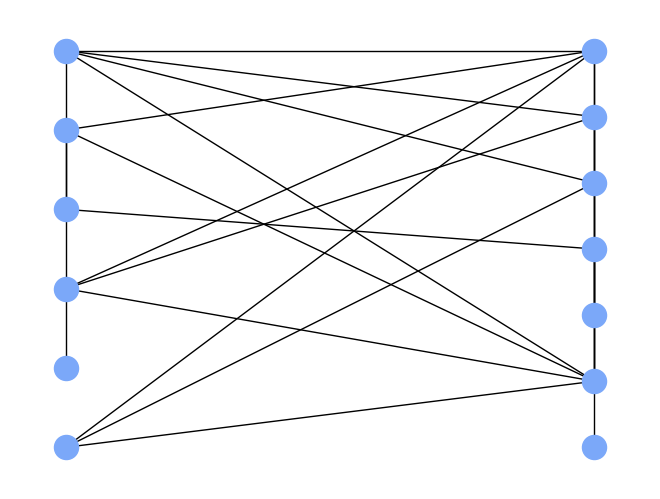

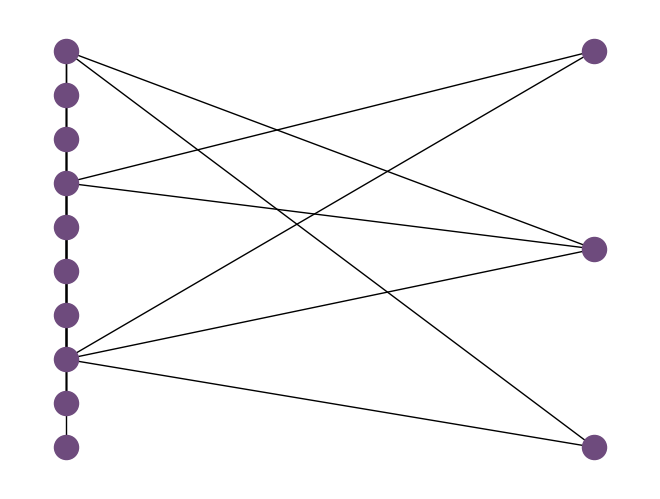

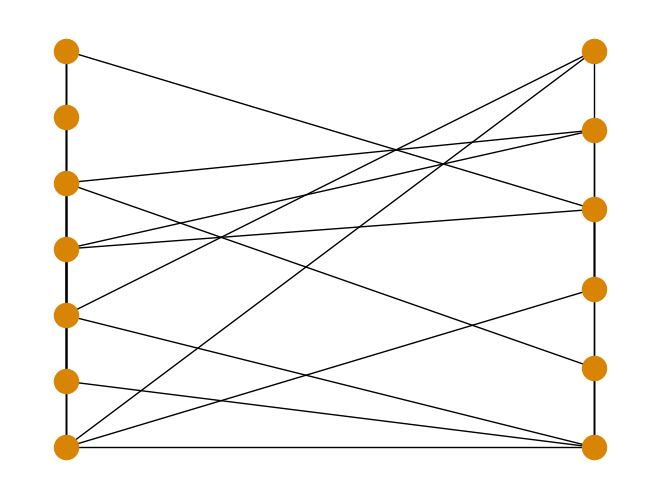

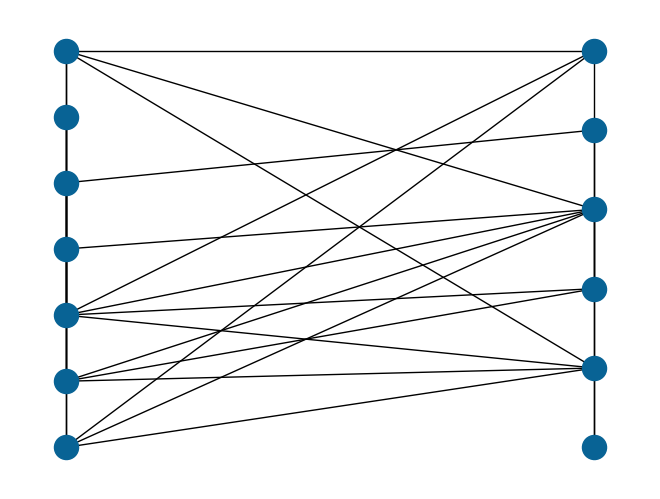

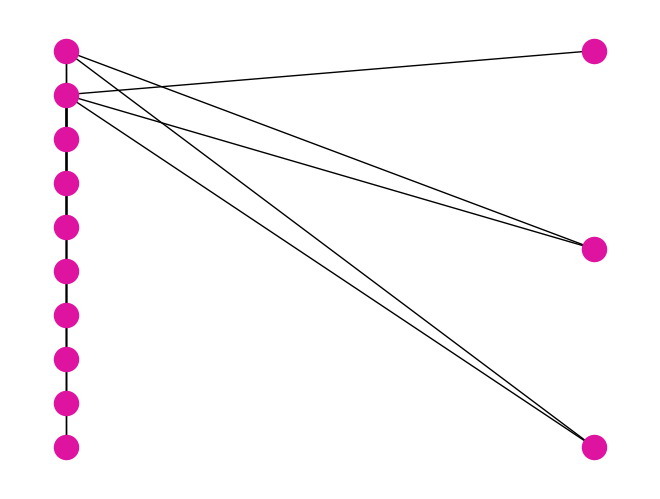

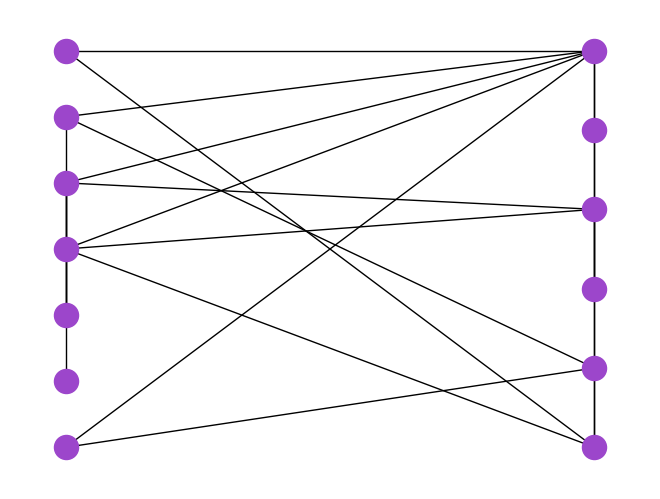

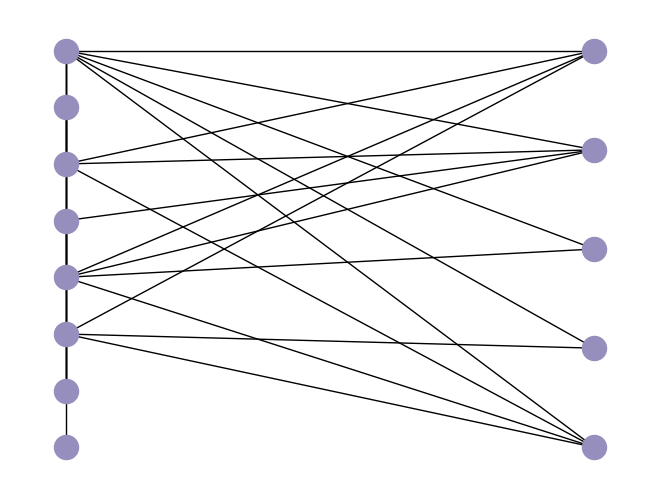

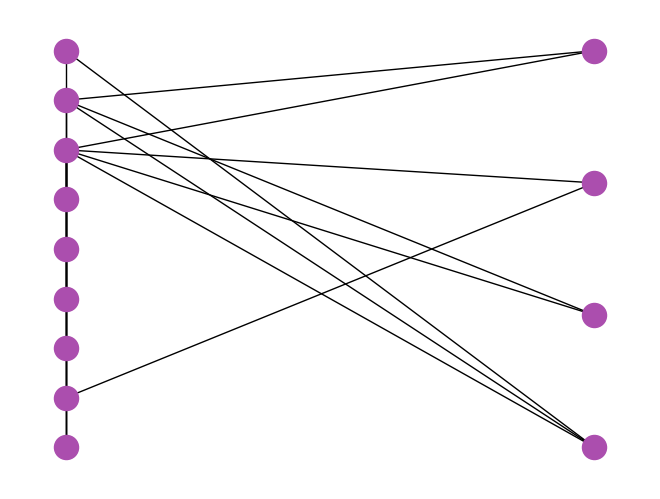

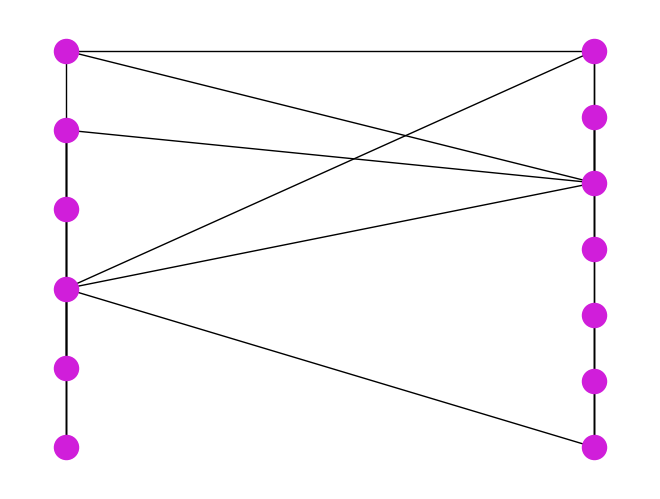

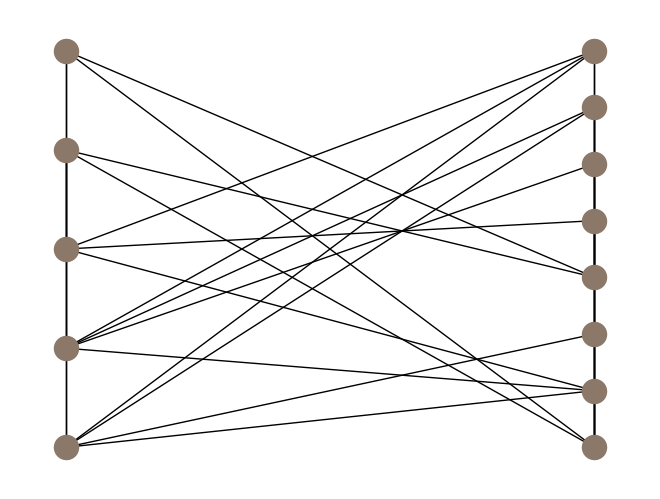

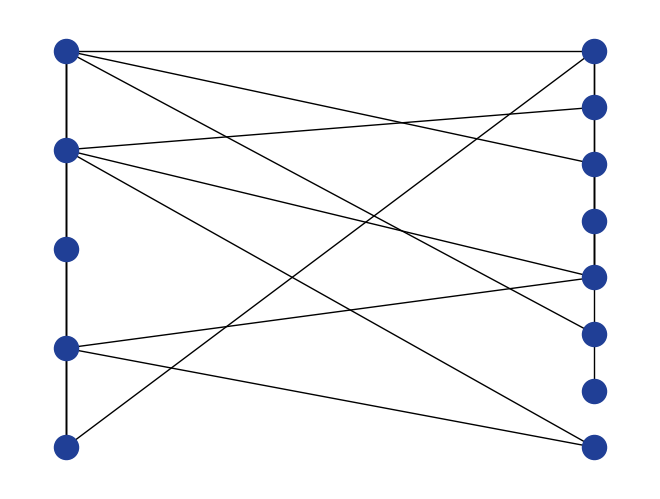

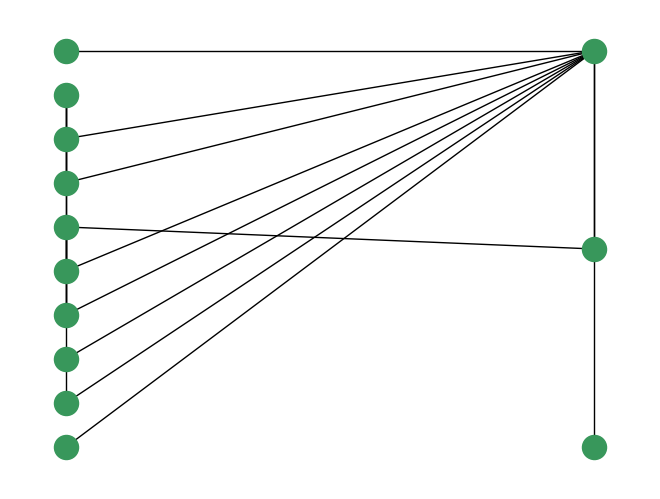

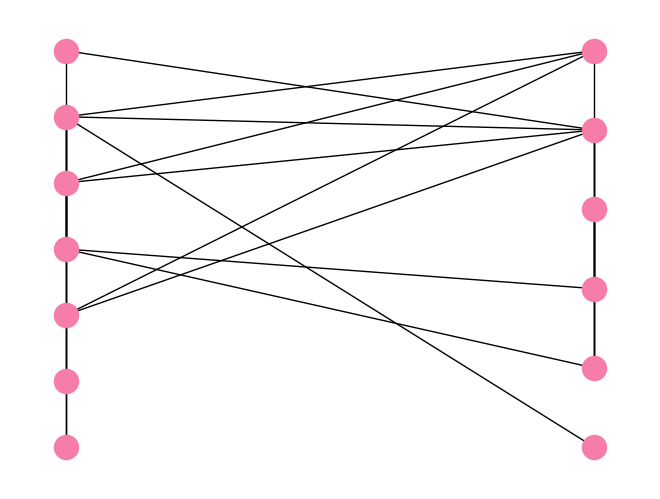

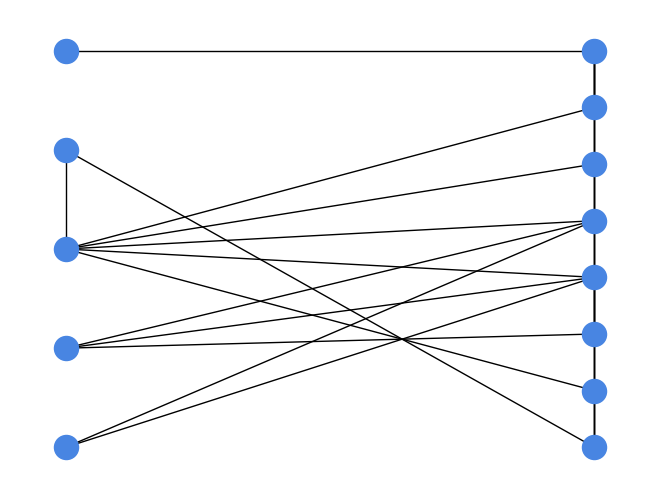

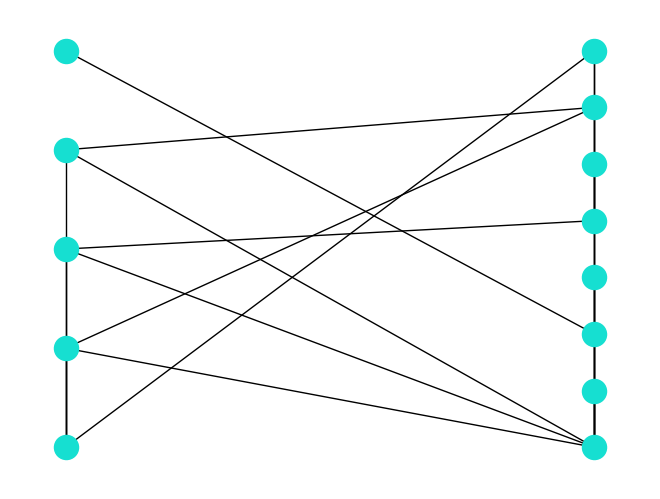

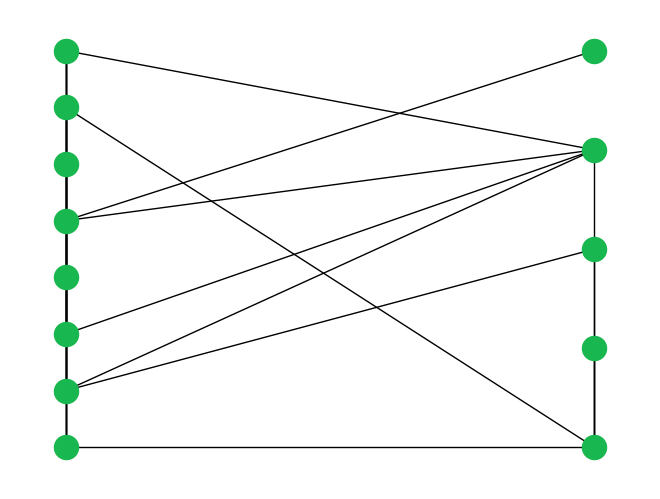

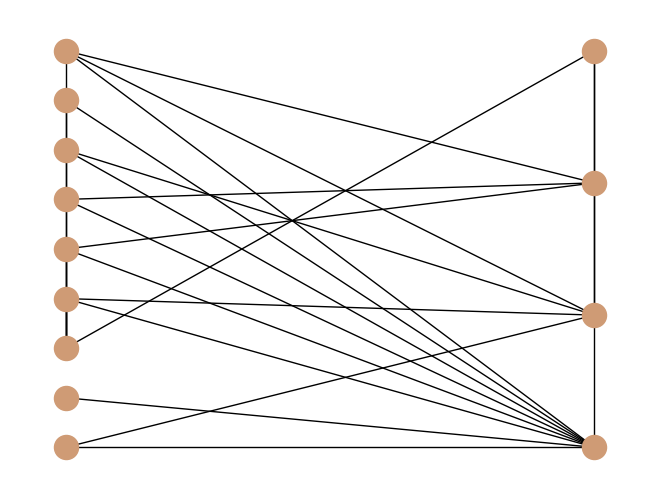

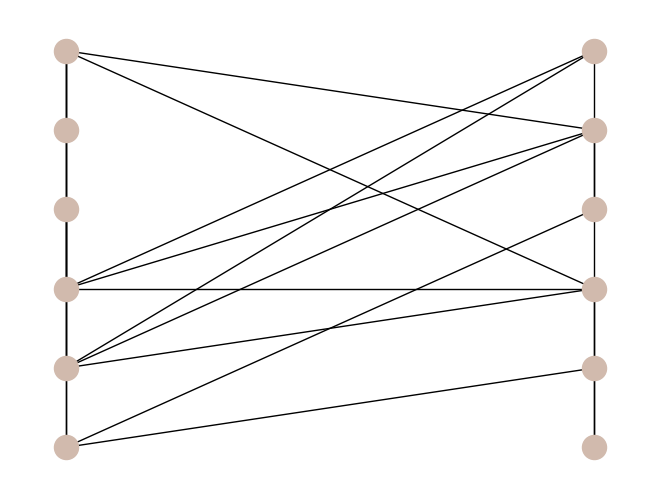

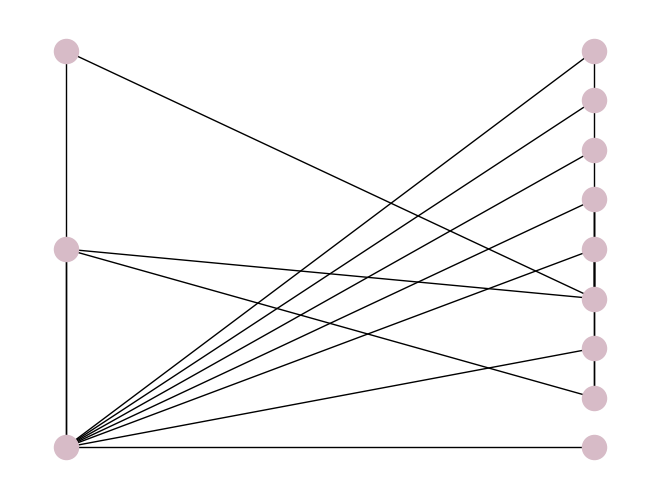

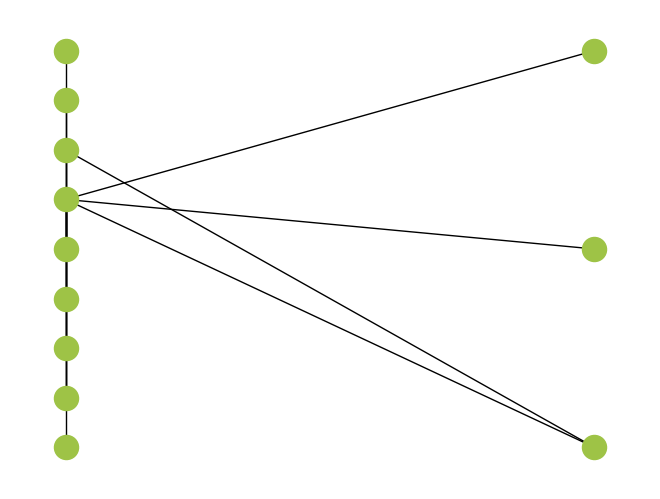

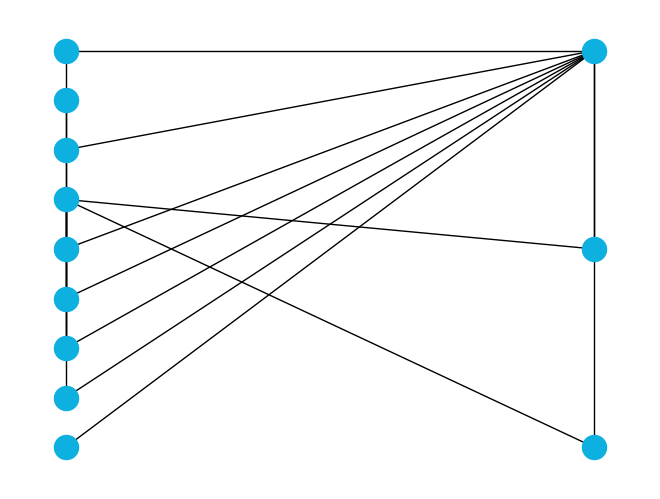

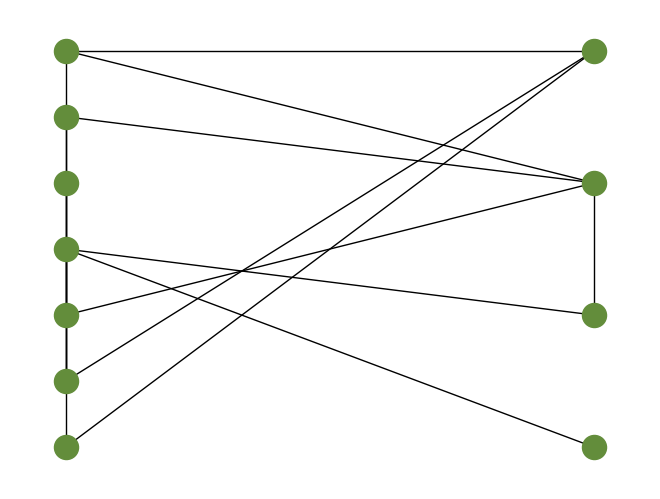

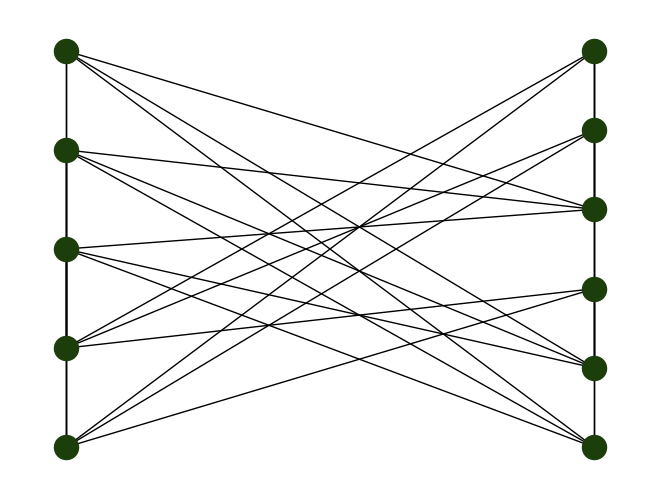

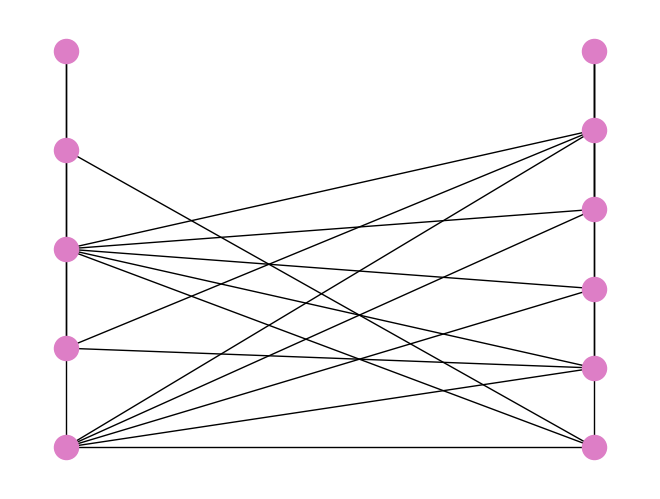

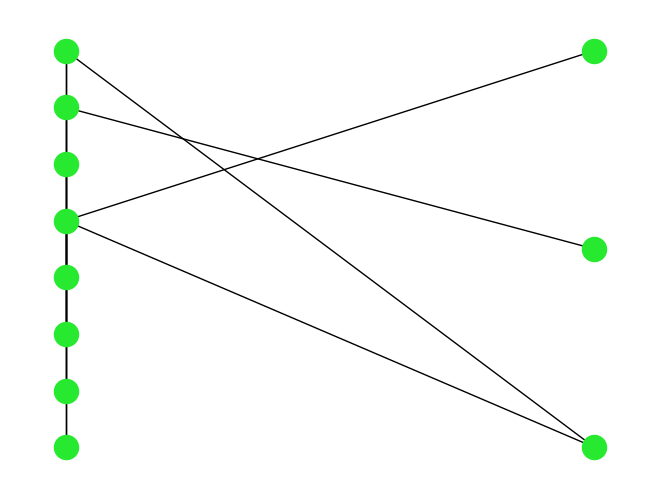

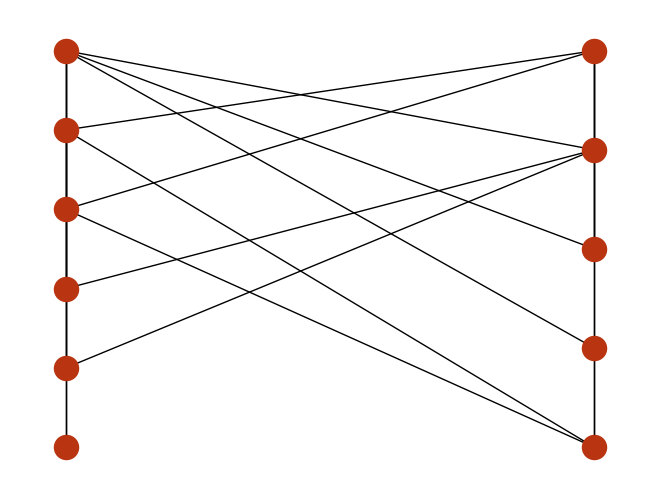

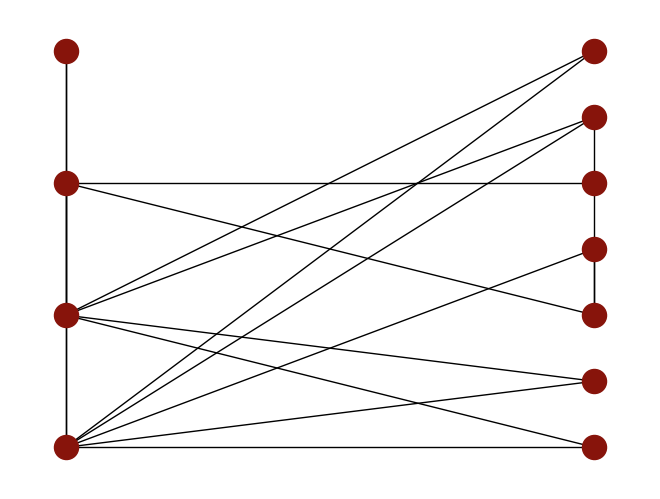

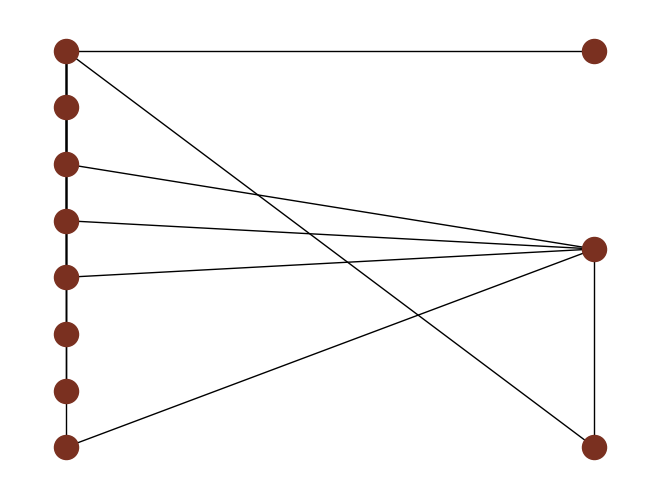

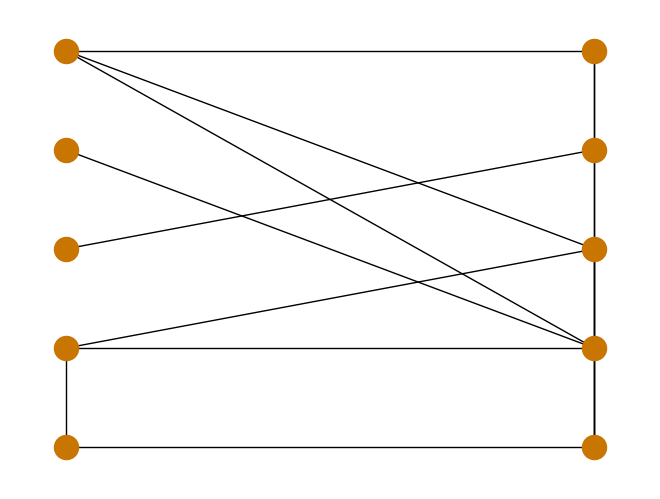

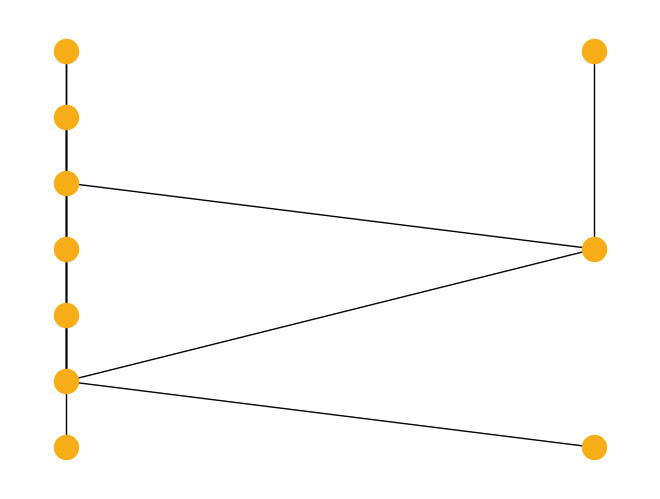

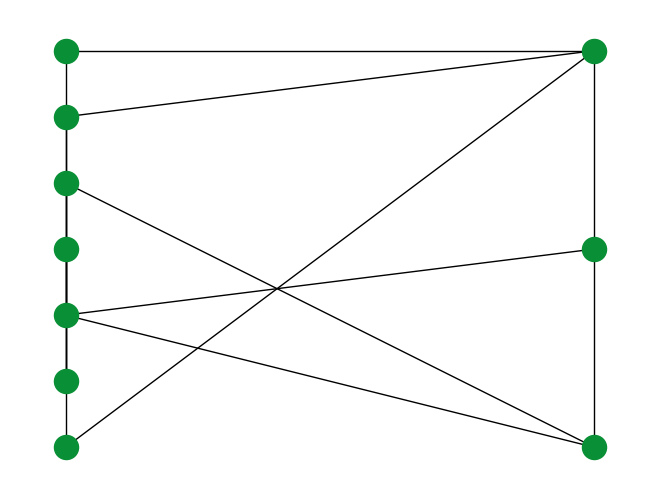

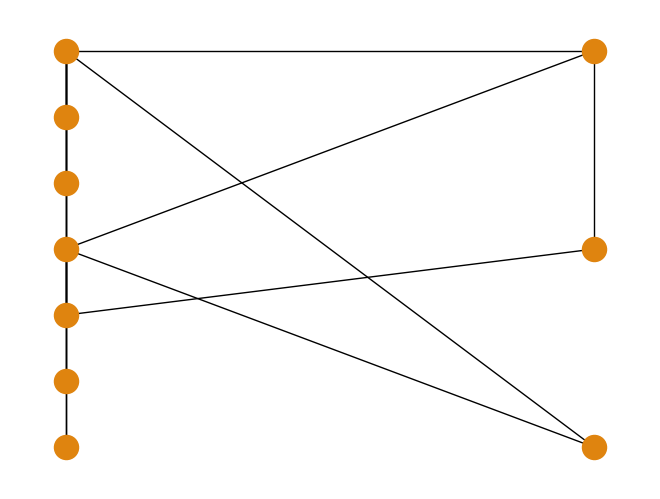

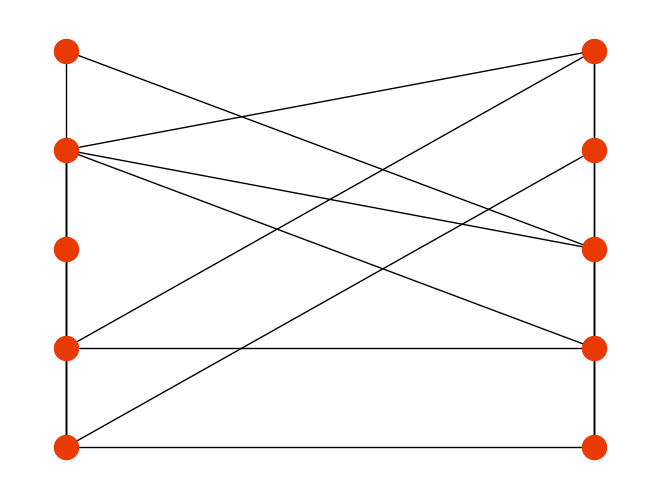

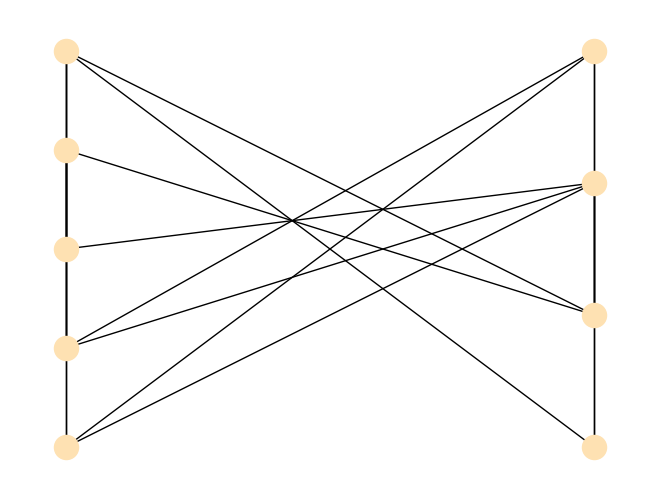

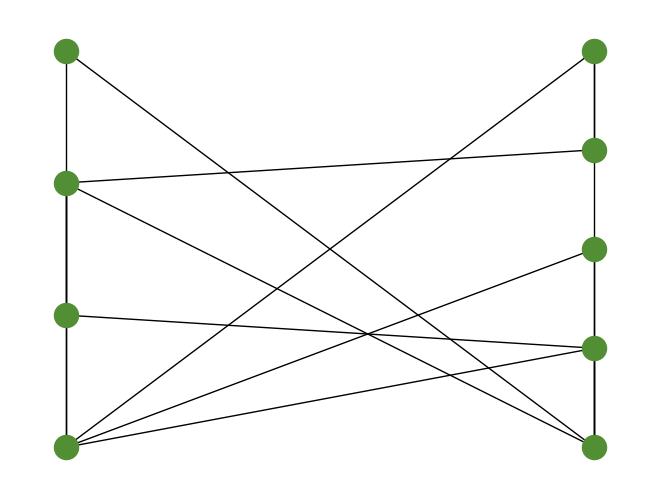

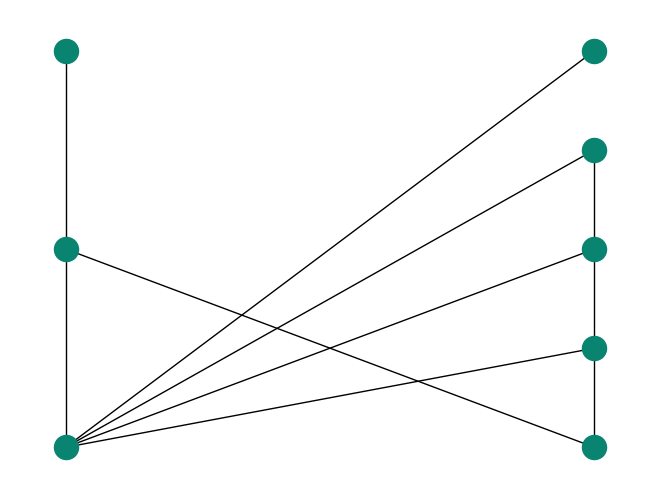

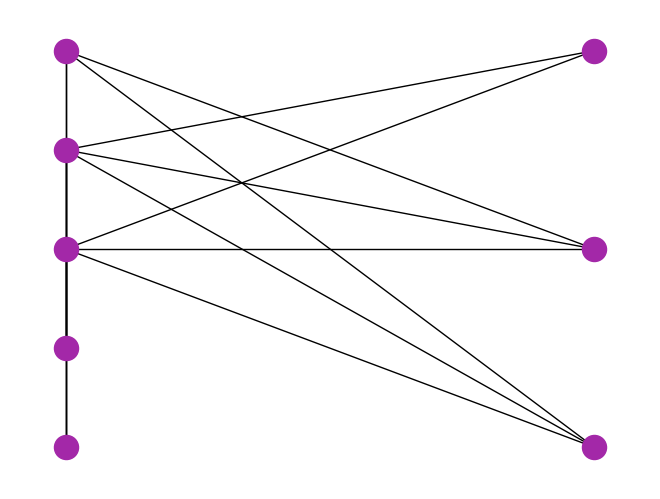

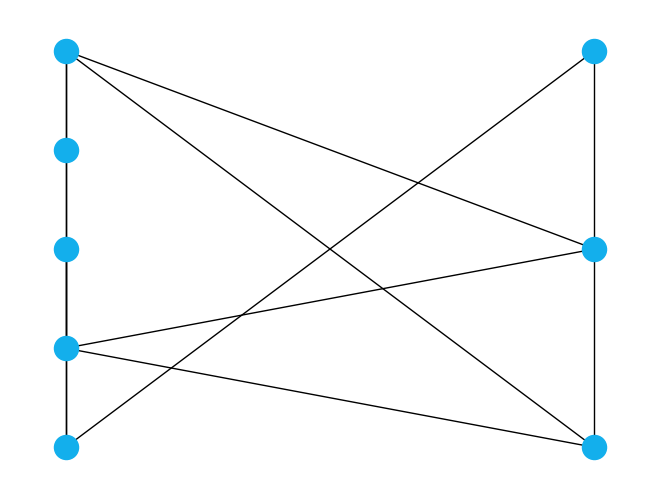

In [27]:
G = create_bipartite_graph(events, entities, relationships)
print(f"Loaded graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

#from networkx.algorithms import bipartite

#print("Is bipartite ", bipartite.is_bipartite(G))
	# show a few sample edges
#for u, v, d in list(G.edges(data=True))[:1000]:
#	print(u, "-", v, ":", d)

from random import randint
comps = connected_components_sorted(G)

for i in range(len(comps)):
    comp = comps[i]
    plt.figure(i)

    color_hex = hex(randint(0, 2**24 - 1))[2:]
    color = '#' + '0' * (6 - len(color_hex)) + color_hex
    
    nx.draw_bipartite(nx.induced_subgraph(G, comp), node_color=color)

print(len(comps))